In [26]:
import numpy as np
import pandas as pd

# ------------------------------
# Question 1a: Compute Conditional Probabilities
# ------------------------------

print("Q1 (1a): Computing Conditional Probabilities")

# Given Twitter stock market data (Confirmed from PDF)
data = pd.DataFrame({
    "Buy": [1, 1, 1, 1, 0, 0, 0, 0, 1],
    "Sell": [1, 0, 0, 0, 1, 1, 1, 0, 1],
    "Inflation Up": [0, 1, 1, 0, 0, 0, 0, 1, 0],
    "Inflation Down": [1, 1, 0, 0, 1, 1, 1, 1, 0],
    "Unemployment High": [0, 0, 0, 1, 1, 1, 1, 0, 1],
    "Unemployment Down": [1, 1, 0, 1, 1, 1, 0, 0, 0],
    "Recession": [0, 0, 0, 1, 1, 1, 1, 0, 1],
    "SP500": ["UP", "UP", "UP", "UP", "DOWN", "DOWN", "DOWN", "DOWN", "DOWN"]
})

# Compute P[1|UP] and P[1|DOWN]
prob_1_given_up = data[data["SP500"] == "UP"].drop(columns=["SP500"]).mean()
prob_1_given_down = data[data["SP500"] == "DOWN"].drop(columns=["SP500"]).mean()

# Compute P[0|UP] and P[0|DOWN] (which is just 1 - P[1|...])
prob_0_given_up = 1 - prob_1_given_up
prob_0_given_down = 1 - prob_1_given_down

# Compute prior probabilities
prior_up = len(data[data["SP500"] == "UP"]) / len(data)
prior_down = len(data[data["SP500"] == "DOWN"]) / len(data)

# Create final probability table
final_prob_table = pd.DataFrame({
    "P[1|UP]": prob_1_given_up,
    "P[0|UP]": prob_0_given_up,
    "P[1|DOWN]": prob_1_given_down,
    "P[0|DOWN]": prob_0_given_down
})

# Add prior probabilities at the bottom
final_prob_table.loc["Prior Probability"] = [prior_up, 1 - prior_up, prior_down, 1 - prior_down]

# Display the table
print("FINAL Corrected Probability Table for Q1 (1a):\n")
print(final_prob_table)

# ------------------------------
# Question 1b: Naïve Bayes Classification
# ------------------------------

print("Q1 (1b): Naïve Bayes Classification")

# New observation
new_data = {"Buy": 1, "Sell": 0, "Inflation Up": 0, "Inflation Down": 1, "Unemployment High": 1, "Unemployment Down": 1, "Recession": 0}

# Compute likelihoods
likelihood_up = prior_up * np.prod([prob_1_given_up[col] if val == 1 else prob_0_given_up[col] for col, val in new_data.items()])
likelihood_down = prior_down * np.prod([prob_1_given_down[col] if val == 1 else prob_0_given_down[col] for col, val in new_data.items()])

# Normalize probabilities
prob_market_up = likelihood_up / (likelihood_up + likelihood_down)
prob_market_down = likelihood_down / (likelihood_up + likelihood_down)

# Print prediction
prediction = "UP" if prob_market_up > prob_market_down else "DOWN"
print(f"Probability Market UP: {prob_market_up:.4f}")
print(f"Probability Market DOWN: {prob_market_down:.4f}")
print(f"Predicted Market Direction: {prediction}")

# ------------------------------
# Question 1c: Naïve Bayes with Laplace Smoothing
# ------------------------------

print("Q1 (1c): Naïve Bayes with Laplace Smoothing")

alpha = 1  # Laplace smoothing factor
beta = len(data.columns) - 1  # Total number of features

# Apply Laplace smoothing
prob_1_given_up_smooth = (data[data["SP500"] == "UP"].drop(columns=["SP500"]).sum() + alpha) / (len(data[data["SP500"] == "UP"]) + beta)
prob_1_given_down_smooth = (data[data["SP500"] == "DOWN"].drop(columns=["SP500"]).sum() + alpha) / (len(data[data["SP500"] == "DOWN"]) + beta)

# Compute smoothed P[0|UP] and P[0|DOWN]
prob_0_given_up_smooth = 1 - prob_1_given_up_smooth
prob_0_given_down_smooth = 1 - prob_1_given_down_smooth

# Compute smoothed likelihoods
likelihood_up_smooth = prior_up * np.prod([prob_1_given_up_smooth[col] if val == 1 else prob_0_given_up_smooth[col] for col, val in new_data.items()])
likelihood_down_smooth = prior_down * np.prod([prob_1_given_down_smooth[col] if val == 1 else prob_0_given_down_smooth[col] for col, val in new_data.items()])

# Normalize probabilities
prob_market_up_smooth = likelihood_up_smooth / (likelihood_up_smooth + likelihood_down_smooth)
prob_market_down_smooth = likelihood_down_smooth / (likelihood_up_smooth + likelihood_down_smooth)

# Print smoothed prediction
prediction_smooth = "UP" if prob_market_up_smooth > prob_market_down_smooth else "DOWN"
print(f"Probability Market UP (Smoothed): {prob_market_up_smooth:.4f}")
print(f"Probability Market DOWN (Smoothed): {prob_market_down_smooth:.4f}")
print(f"Predicted Market Direction (Smoothed): {prediction_smooth}")


Q1 (1a): Computing Conditional Probabilities
FINAL Corrected Probability Table for Q1 (1a):

                    P[1|UP]   P[0|UP]  P[1|DOWN]  P[0|DOWN]
Buy                1.000000  0.000000   0.200000   0.800000
Sell               0.250000  0.750000   0.800000   0.200000
Inflation Up       0.500000  0.500000   0.200000   0.800000
Inflation Down     0.500000  0.500000   0.800000   0.200000
Unemployment High  0.250000  0.750000   0.800000   0.200000
Unemployment Down  0.750000  0.250000   0.400000   0.600000
Recession          0.250000  0.750000   0.800000   0.200000
Prior Probability  0.444444  0.555556   0.555556   0.444444
Q1 (1b): Naïve Bayes Classification
Probability Market UP: 0.9279
Probability Market DOWN: 0.0721
Predicted Market Direction: UP
Q1 (1c): Naïve Bayes with Laplace Smoothing
Probability Market UP (Smoothed): 0.6088
Probability Market DOWN (Smoothed): 0.3912
Predicted Market Direction (Smoothed): UP



🔹 Q2 (2a): Generating and plotting data


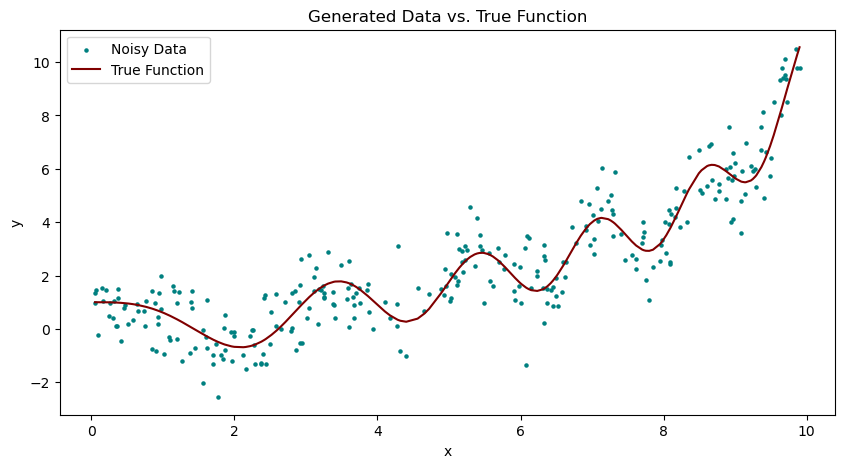

Q2 (2b): Finding best k using GridSearchCV
Best k: 11, Best Score (negative RMSE): -0.9629
Q2 (2d): Plotting k vs. MSE


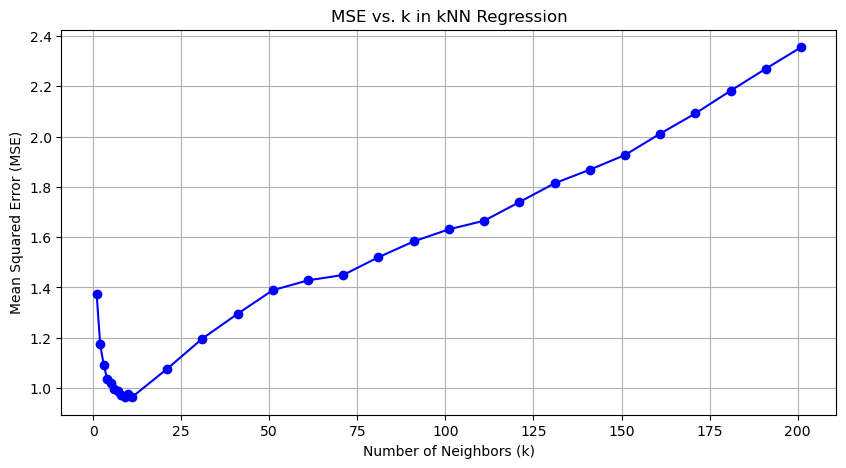

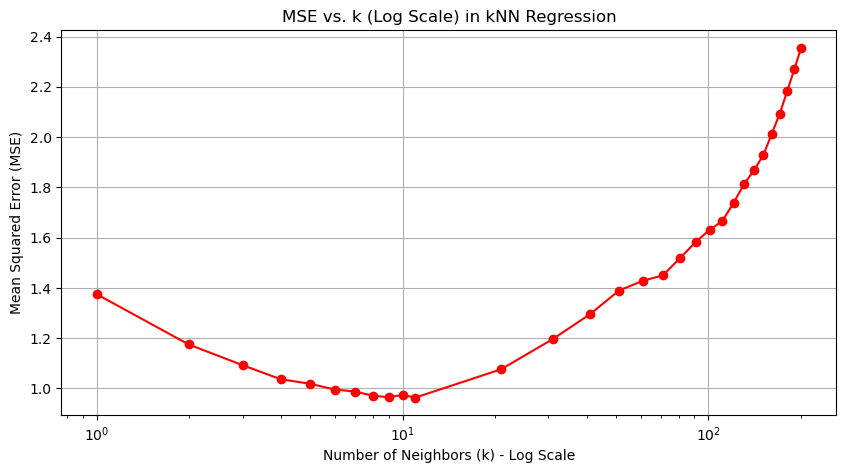

Q2 (2e): Plotting estimated functions for different k values


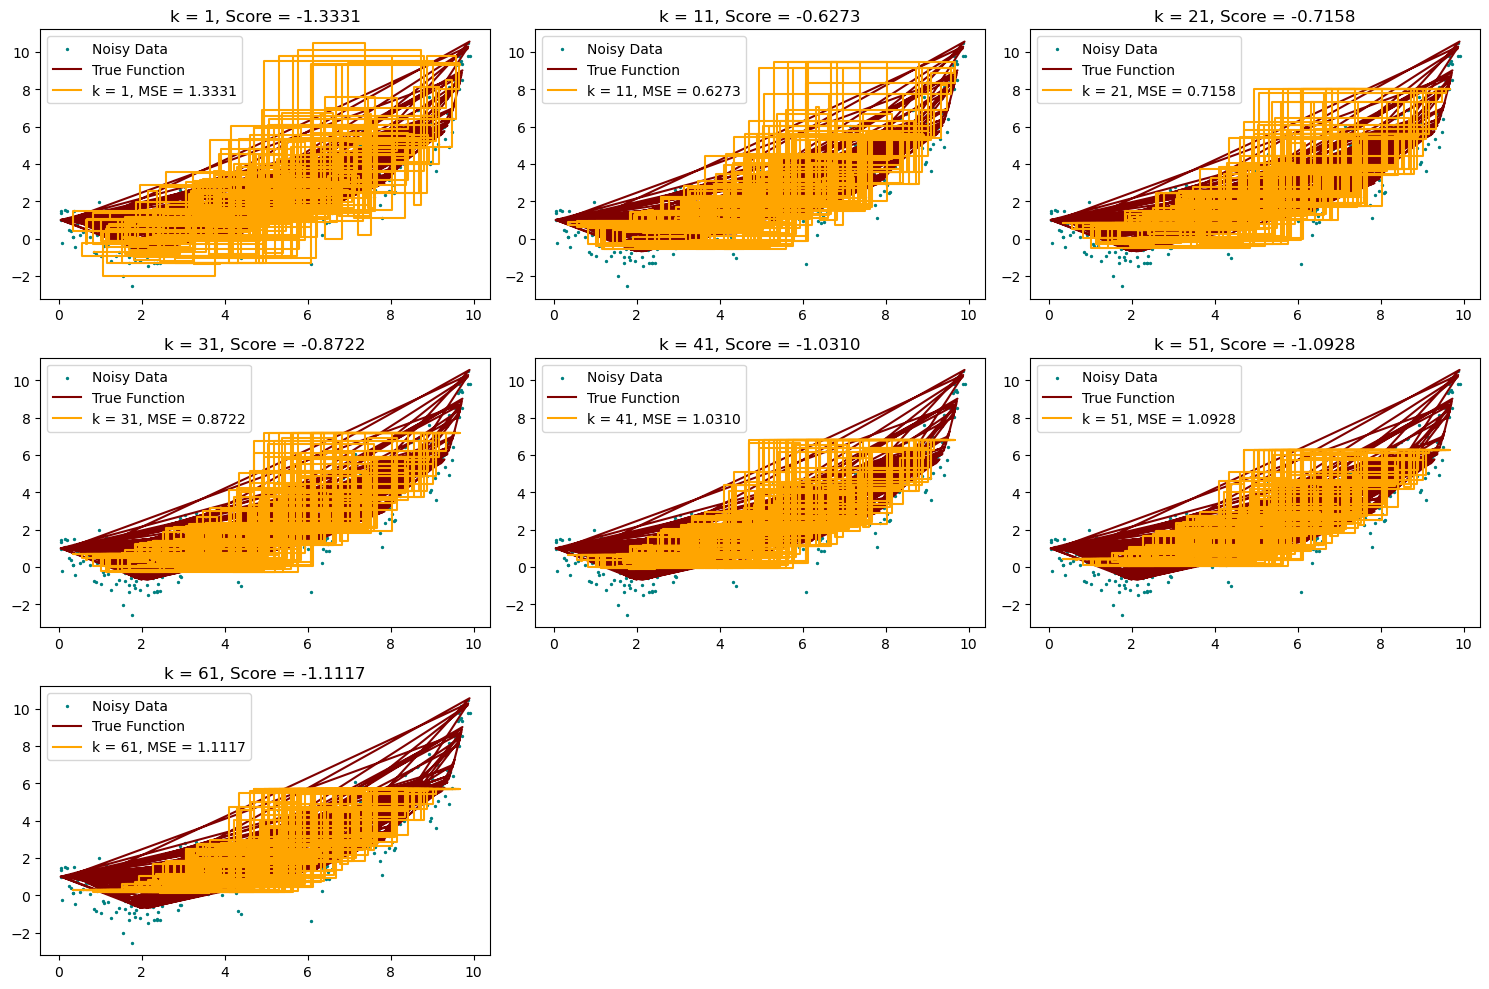

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# ------------------------------
# Question 2a: Generate and plot 300 data points
# ------------------------------

print("\n🔹 Q2 (2a): Generating and plotting data")

# Define the function
def f(x):
    return np.cos(x**1.5) + 5 * np.log(np.tan(x**2 / 70) + 1)

# Generate 300 random x values
np.random.seed(42)
x = np.random.uniform(0, 10, 300)
y = f(x) + np.random.normal(0, 0.9, 300)  # Add noise

# Plot the data
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color="teal", s=5, label="Noisy Data")
plt.plot(np.sort(x), f(np.sort(x)), color="maroon", label="True Function")
plt.legend()
plt.title("Generated Data vs. True Function")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# ------------------------------
# Question 2b: Use cross-validation to find the best k
# ------------------------------

print("Q2 (2b): Finding best k using GridSearchCV")

# Reshape x for sklearn compatibility
x = x.reshape(-1, 1)

# Split into train and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define k values: {1, 2, ..., 10} ∪ {11, 21, ..., 201}
k_values = list(range(1, 11)) + list(range(11, 202, 10))

# Define GridSearchCV with negative MSE scoring
knn_model = KNeighborsRegressor()
param_grid = {"n_neighbors": k_values}
grid_search = GridSearchCV(knn_model, param_grid, scoring="neg_root_mean_squared_error", cv=10)
grid_search.fit(x_train, y_train)

# ------------------------------
# Question 2c: Identify best k and best score
# ------------------------------

best_k = grid_search.best_params_["n_neighbors"]
best_score = grid_search.best_score_

print(f"Best k: {best_k}, Best Score (negative RMSE): {best_score:.4f}")

# ------------------------------
# Question 2d: Plot k values vs. scores
# ------------------------------

print("Q2 (2d): Plotting k vs. MSE")

mse_values = -grid_search.cv_results_["mean_test_score"]

plt.figure(figsize=(10, 5))
plt.plot(k_values, mse_values, marker="o", linestyle="-", color="blue")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs. k in kNN Regression")
plt.grid()
plt.show()

# Log scale plot
plt.figure(figsize=(10, 5))
plt.semilogx(k_values, mse_values, marker="o", linestyle="-", color="red")
plt.xlabel("Number of Neighbors (k) - Log Scale")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs. k (Log Scale) in kNN Regression")
plt.grid()
plt.show()

# ------------------------------
# Question 2e: Plot estimated functions for different k values
# ------------------------------

print("Q2 (2e): Plotting estimated functions for different k values")

k_test_values = [1, 11, 21, 31, 41, 51, 61]

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_test_values):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(np.sort(x).reshape(-1, 1))
    mse_score = mean_squared_error(y_test, knn.predict(x_test))

    plt.subplot(3, 3, i + 1)
    plt.scatter(x, y, color="teal", s=2, label="Noisy Data")
    plt.plot(np.sort(x), f(np.sort(x)), color="maroon", label="True Function")
    plt.step(np.sort(x), y_pred, color="orange", where="mid", label=f"k = {k}, MSE = {mse_score:.4f}")
    plt.legend()
    plt.title(f"k = {k}, Score = {-mse_score:.4f}")

plt.tight_layout()
plt.show()


Q3 (3a): Loading Fashion-MNIST dataset
Dataset loaded. Training samples: 56000, Testing samples: 14000
Q3 (3b): Applying PCA
Total explained variance after PCA: 0.86
Q3 (3c): Training kNN classifier with GridSearchCV
Best k: 11, Best Metric: cosine, Best Accuracy: 0.8577
Q3 (3e): Evaluating best kNN model
kNN Classifier Accuracy: 0.8616

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81      1373
           1       0.99      0.96      0.98      1387
           2       0.77      0.81      0.79      1396
           3       0.88      0.88      0.88      1379
           4       0.77      0.82      0.79      1447
           5       0.96      0.90      0.93      1384
           6       0.71      0.55      0.62      1468
           7       0.91      0.94      0.92      1411
           8       0.95      0.96      0.96      1425
           9       0.91      0.95      0.93      1330

    accuracy                           0.

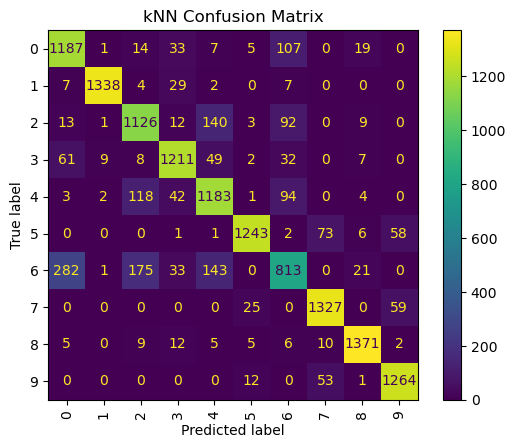

Q3 (3f): Comparing kNN with Naïve Bayes
Naïve Bayes Accuracy: 0.7752


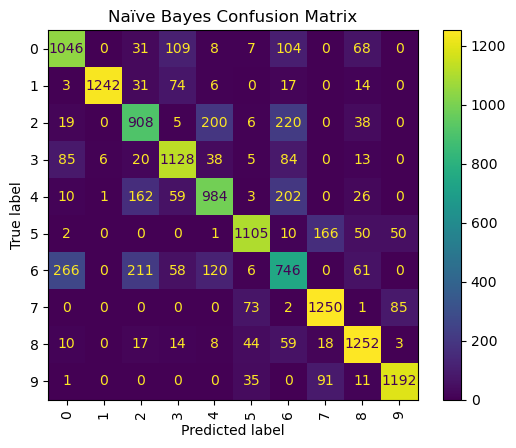

Q3 (3g): Displaying side-by-side comparisons of kNN and Naïve Bayes


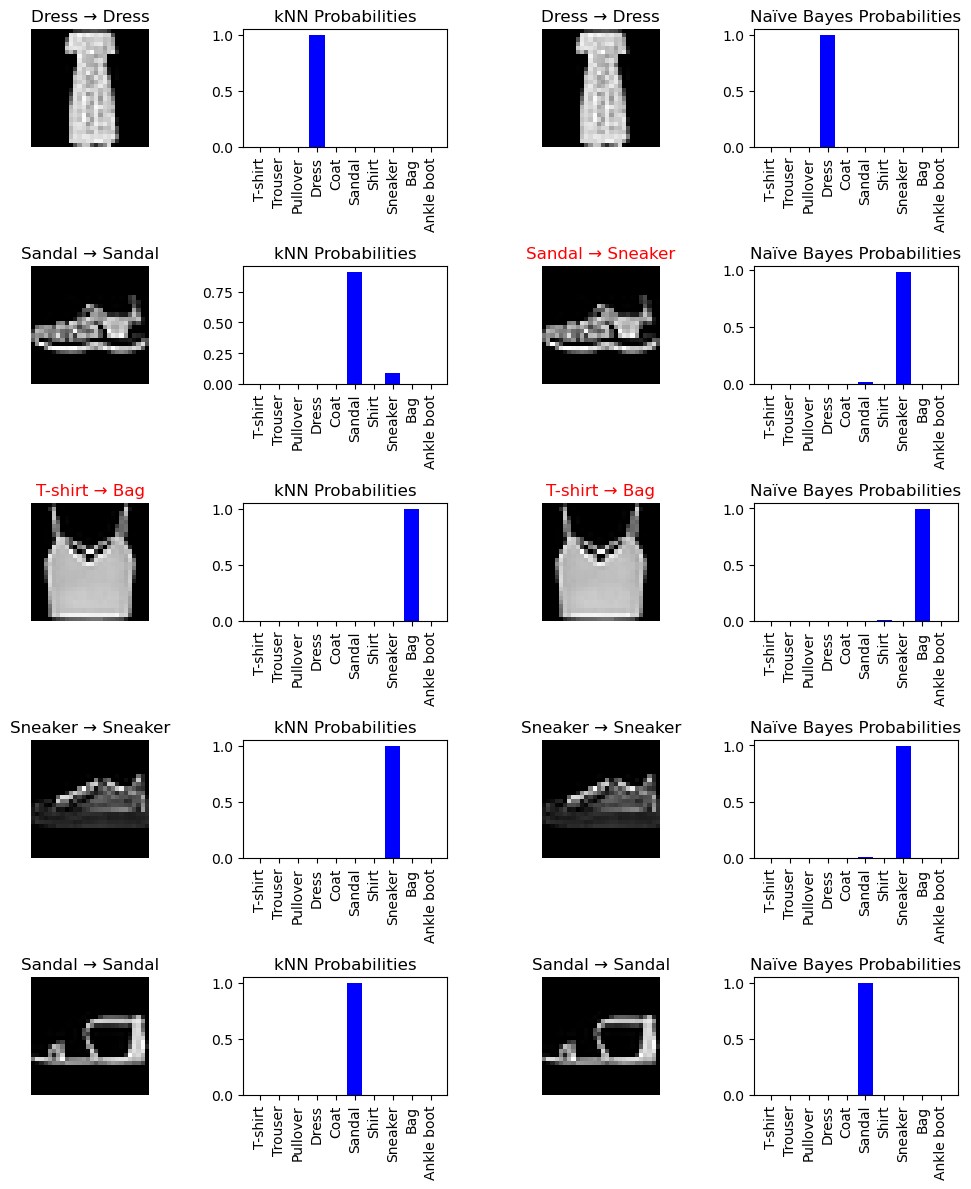

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from random import sample

# ------------------------------
# Question 3a: Load and preprocess Fashion-MNIST dataset
# ------------------------------

print("Q3 (3a): Loading Fashion-MNIST dataset")

# Load Fashion-MNIST from OpenML
X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False)

# Normalize pixel values to range [0,1]
X = X / 255.0

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

print(f"Dataset loaded. Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ------------------------------
# Question 3b: Perform PCA for dimensionality reduction
# ------------------------------

print("Q3 (3b): Applying PCA")

pca = PCA(n_components=50)  # Reduce to 50 dimensions
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total explained variance after PCA: {explained_variance:.2f}")

# ------------------------------
# Question 3c: Train kNN classifier with cross-validation
# ------------------------------

print("Q3 (3c): Training kNN classifier with GridSearchCV")

k_values = list(range(1, 102, 10))
metrics = ["euclidean", "cosine"]
param_grid = {"n_neighbors": k_values, "metric": metrics}

knn_model = KNeighborsClassifier()
grid_search = GridSearchCV(knn_model, param_grid, cv=5)
grid_search.fit(X_train_pca, y_train)

# ------------------------------
# Question 3d: Identify best k and accuracy
# ------------------------------

best_k = grid_search.best_params_["n_neighbors"]
best_metric = grid_search.best_params_["metric"]
best_accuracy = grid_search.best_score_

print(f"Best k: {best_k}, Best Metric: {best_metric}, Best Accuracy: {best_accuracy:.4f}")

# ------------------------------
# Question 3e: Generate classification report and confusion matrix
# ------------------------------

print("Q3 (3e): Evaluating best kNN model")

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(X_train_pca, y_train)
y_pred_knn = knn_best.predict(X_test_pca)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"kNN Classifier Accuracy: {accuracy_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, xticks_rotation="vertical")
plt.title("kNN Confusion Matrix")
plt.show()

# ------------------------------
# Question 3f: Compare kNN with Naïve Bayes
# ------------------------------

print("Q3 (3f): Comparing kNN with Naïve Bayes")

nb = GaussianNB()
nb.fit(X_train_pca, y_train)
y_pred_nb = nb.predict(X_test_pca)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"Naïve Bayes Accuracy: {accuracy_nb:.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, xticks_rotation="vertical")
plt.title("Naïve Bayes Confusion Matrix")
plt.show()

# ------------------------------
# Question 3g: Generate side-by-side comparisons of kNN and Naïve Bayes
# ------------------------------

print("Q3 (3g): Displaying side-by-side comparisons of kNN and Naïve Bayes")

# Mapping integer labels to clothing categories
class_labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Select 5 random images
random_indices = sample(range(len(X_test)), 5)
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(10, 12))

for i, idx in enumerate(random_indices):
    img = X_test[idx].reshape(28, 28)
    
    true_label = class_labels[int(y_test[idx])]
    pred_knn = class_labels[int(y_pred_knn[idx])]
    pred_nb = class_labels[int(y_pred_nb[idx])]

    # Color-coding for correctness
    knn_color = "black" if true_label == pred_knn else "red"
    nb_color = "black" if true_label == pred_nb else "red"

    # Plot original image (first column)
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].axis("off")
    axes[i, 0].set_title(f"{true_label} → {pred_knn}", color=knn_color)

    # kNN probability bar chart (second column)
    knn_probs = knn_best.predict_proba(X_test_pca[idx].reshape(1, -1))[0]
    axes[i, 1].bar(range(10), knn_probs, color="blue")
    axes[i, 1].set_xticks(range(10))
    axes[i, 1].set_xticklabels(class_labels, rotation=90)
    axes[i, 1].set_title("kNN Probabilities")

    # Naïve Bayes prediction (third column)
    axes[i, 2].imshow(img, cmap="gray")
    axes[i, 2].axis("off")
    axes[i, 2].set_title(f"{true_label} → {pred_nb}", color=nb_color)

    # Naïve Bayes probability bar chart (fourth column)
    nb_probs = nb.predict_proba(X_test_pca[idx].reshape(1, -1))[0]
    axes[i, 3].bar(range(10), nb_probs, color="blue")
    axes[i, 3].set_xticks(range(10))
    axes[i, 3].set_xticklabels(class_labels, rotation=90)
    axes[i, 3].set_title("Naïve Bayes Probabilities")

plt.tight_layout()
plt.show()


In [42]:
import numpy as np
import pandas as pd
import math

# ------------------------------
# Question 4a: Compute Term Frequencies (TF) for each document
# ------------------------------

print("Q4 (4a): Computing Term Frequencies (TF)")

# Define the four documents
documents = [
    "Seven touchdowns were scored in the game yesterday",
    "Landing the contract was a big score",
    "The game ended with a lopsided score",
    "The business contract was finally signed yesterday"
]

# Preprocess text (convert to lowercase and split into words)
docs_lower = [doc.lower().split() for doc in documents]

# Define keywords for TF-IDF analysis
keywords = ["touchdowns", "score", "contract", "yesterday"]

# Compute TF for each document
tf_matrix = {keyword: [doc.count(keyword) / len(doc) for doc in docs_lower] for keyword in keywords}

# Convert to DataFrame
tf_df = pd.DataFrame(tf_matrix, index=[f"Doc {i+1}" for i in range(len(documents))])

print("Term Frequency (TF) Matrix:")
print(tf_df)

# ------------------------------
# Question 4b: Compute Inverse Document Frequency (IDF)
# ------------------------------

print("Q4 (4b): Computing Inverse Document Frequency (IDF)")

# Number of documents
num_docs = len(documents)

# Compute IDF for each keyword
idf_scores = {
    keyword: math.log(num_docs / (1 + sum([1 for doc in docs_lower if keyword in doc])))
    for keyword in keywords
}

# Convert to DataFrame
idf_df = pd.DataFrame.from_dict(idf_scores, orient="index", columns=["IDF"])

print("Inverse Document Frequency (IDF) Scores:")
print(idf_df)

# ------------------------------
# Question 4c: Compute Term Frequency-Inverse Document Frequency (TF-IDF)
# ------------------------------

print("Q4 (4c): Computing TF-IDF Matrix")

# Compute TF-IDF by multiplying TF with IDF
tfidf_matrix = tf_df.copy()
for keyword in keywords:
    tfidf_matrix[keyword] = tf_df[keyword] * idf_scores[keyword]

print("TF-IDF Matrix:")
print(tfidf_matrix)


Q4 (4a): Computing Term Frequencies (TF)
Term Frequency (TF) Matrix:
       touchdowns     score  contract  yesterday
Doc 1       0.125  0.000000  0.000000   0.125000
Doc 2       0.000  0.142857  0.142857   0.000000
Doc 3       0.000  0.142857  0.000000   0.000000
Doc 4       0.000  0.000000  0.142857   0.142857
Q4 (4b): Computing Inverse Document Frequency (IDF)
Inverse Document Frequency (IDF) Scores:
                 IDF
touchdowns  0.693147
score       0.287682
contract    0.287682
yesterday   0.287682
Q4 (4c): Computing TF-IDF Matrix
TF-IDF Matrix:
       touchdowns     score  contract  yesterday
Doc 1    0.086643  0.000000  0.000000   0.035960
Doc 2    0.000000  0.041097  0.041097   0.000000
Doc 3    0.000000  0.041097  0.000000   0.000000
Doc 4    0.000000  0.000000  0.041097   0.041097


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 5a: Load dataset
news_data = fetch_openml(name='news_channel', as_frame=True)
newsDF = news_data.data  # Features
newsTarget = pd.Series(news_data.target)  # Labels
newsCorpus = newsDF['article_title'].dropna().tolist()  # List of article titles

# 5b: TF-IDF vectorization
vectorizer = TfidfVectorizer(sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")
X = vectorizer.fit_transform(newsCorpus)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, newsTarget.iloc[:X.shape[0]], test_size=0.2, random_state=42)

# 5c: kNN classification with GridSearchCV
param_grid = {'n_neighbors': np.arange(1, 202, 10), 'metric': ['euclidean', 'cosine']}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Evaluate best model
y_pred = grid_search.best_estimator_.predict(X_test)
print("Best Parameters (Text Features):", grid_search.best_params_)
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.show()

# 5d: kNN using numerical features
numerical_features = newsDF.drop(columns=['article_title'], errors='ignore').select_dtypes(include=[np.number]).dropna()
X_train_num, X_test_num, y_train, y_test = train_test_split(numerical_features, newsTarget.loc[numerical_features.index], test_size=0.2, random_state=42)

grid_search_num = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search_num.fit(X_train_num, y_train)

# Evaluate best model for numerical features
y_pred_num = grid_search_num.best_estimator_.predict(X_test_num)
print("Best Parameters (Numerical Features):", grid_search_num.best_params_)
print(classification_report(y_test, y_pred_num))
